In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from astroML.datasets import generate_mu_z
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [3]:
z_sample, mu_sample, dmu = generate_mu_z(
    100,
    random_state=1234
)

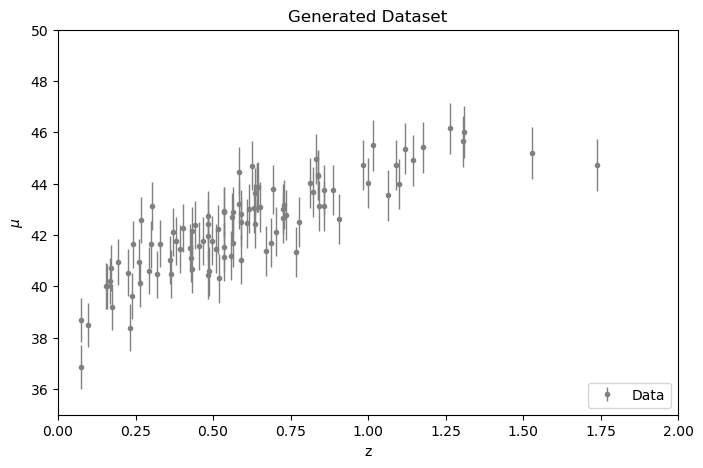

In [4]:
plt.figure(figsize=(8,5))
plt.errorbar(
    z_sample,
    mu_sample,
    dmu,
    fmt='.',
    color='gray',
    lw=1,
    label='Data'
)

plt.xlabel('z')
plt.ylabel('$\\mu$')
plt.legend(loc='lower right')
plt.xlim(0,2)
plt.ylim(35,50)
plt.title('Generated Dataset')
plt.show()

In [5]:
X = z_sample.reshape(-1,1)
y = mu_sample

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

### Polynomial regression models

In [6]:
train_errors = []
val_errors = []
cv_scores = []

In [7]:
max_degree = 10

In [8]:
for degree in range(1, max_degree+1):
    model = make_pipeline(
        PolynomialFeatures(degree),
        LinearRegression()
    )

    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_val_pred = model.predict(X_val)

    train_mse = mean_squared_error(y_train, y_train_pred)
    val_mse = mean_squared_error(y_val, y_val_pred)

    train_errors.append(train_mse)
    val_errors.append(val_mse)

    scores = cross_val_score(
        model,
        X,
        y,
        cv=5,
        scoring='neg_mean_squared_error'
    )

    cv_mse = -scores.mean()
    cv_scores.append(cv_mse)

    print(f"Degree {degree}")
    print(f"Train MSE: {train_mse:.4f}")
    print(f"Validation MSE: {val_mse:.4f}")
    print(f"CV MSE: {cv_mse:.4f}")
    print('-' * 40)

Degree 1
Train MSE: 1.0216
Validation MSE: 0.7796
CV MSE: 1.0020
----------------------------------------
Degree 2
Train MSE: 0.8034
Validation MSE: 0.9095
CV MSE: 0.8949
----------------------------------------
Degree 3
Train MSE: 0.8034
Validation MSE: 0.9091
CV MSE: 0.9443
----------------------------------------
Degree 4
Train MSE: 0.7526
Validation MSE: 0.8304
CV MSE: 1.1143
----------------------------------------
Degree 5
Train MSE: 0.7467
Validation MSE: 0.8025
CV MSE: 0.9659
----------------------------------------
Degree 6
Train MSE: 0.7439
Validation MSE: 0.7956
CV MSE: 4.5891
----------------------------------------
Degree 7
Train MSE: 0.7077
Validation MSE: 0.8440
CV MSE: 2.3409
----------------------------------------
Degree 8
Train MSE: 0.7077
Validation MSE: 0.8436
CV MSE: 1.8001
----------------------------------------
Degree 9
Train MSE: 0.7077
Validation MSE: 0.8462
CV MSE: 25.4836
----------------------------------------
Degree 10
Train MSE: 0.7006
Validation MSE: 0

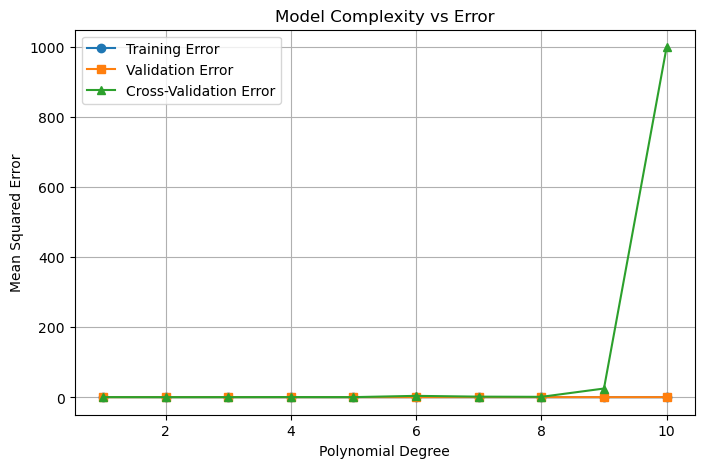

In [9]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, max_degree + 1), train_errors, 'o-', label='Training Error')
plt.plot(range(1, max_degree + 1), val_errors, 's-', label='Validation Error')
plt.plot(range(1, max_degree + 1), cv_scores, '^-', label='Cross-Validation Error')

plt.xlabel('Polynomial Degree')
plt.ylabel('Mean Squared Error')
plt.title('Model Complexity vs Error')
plt.legend()
plt.grid(True)
plt.show()

In [10]:
best_degree = np.argmin(cv_scores) + 1
print(f"Best polynomial degree from CV: {best_degree}")

Best polynomial degree from CV: 2


In [11]:
best_model = make_pipeline(
    PolynomialFeatures(best_degree),
    LinearRegression()
)

best_model.fit(X_train, y_train)

,steps,"[('polynomialfeatures', ...), ('linearregression', ...)]"
,transform_input,None
,memory,None
,verbose,False
,degree,np.int64(2)
,interaction_only,False
,include_bias,True
,order,'C'
,fit_intercept,True
,copy_X,True
,tol,1e-06


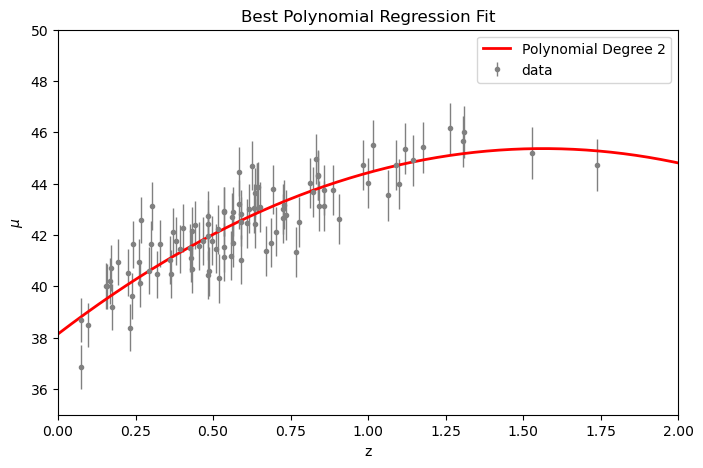

In [12]:
z_fit = np.linspace(0, 2, 500).reshape(-1, 1)
mu_fit = best_model.predict(z_fit)

plt.figure(figsize=(8, 5))

plt.errorbar(
    z_sample,
    mu_sample,
    dmu,
    fmt='.',
    color='gray',
    lw=1,
    label='data'
)

plt.plot(
    z_fit,
    mu_fit,
    color='red',
    lw=2,
    label=f'Polynomial Degree {best_degree}'
)

plt.xlabel('z')
plt.ylabel('$\\mu$')
plt.title('Best Polynomial Regression Fit')
plt.legend()
plt.xlim(0, 2)
plt.ylim(35, 50)
plt.show()

In [14]:
from sklearn.kernel_ridge import KernelRidge

In [15]:
kernel_model = KernelRidge(
    alpha=0.01,
    kernel='rbf',
    gamma=10
)

kernel_model.fit(X_train, y_train)

mu_kernel = kernel_model.predict(z_fit)

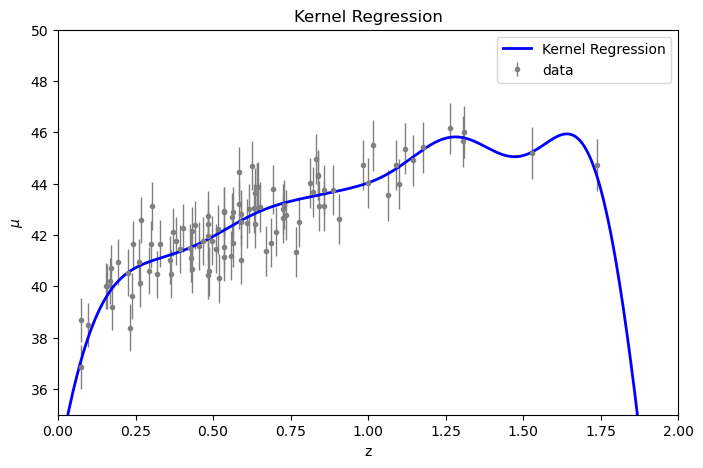

In [16]:
plt.figure(figsize=(8, 5))

plt.errorbar(
    z_sample,
    mu_sample,
    dmu,
    fmt='.',
    color='gray',
    lw=1,
    label='data'
)

plt.plot(
    z_fit,
    mu_kernel,
    color='blue',
    lw=2,
    label='Kernel Regression'
)

plt.xlabel('z')
plt.ylabel('$\\mu$')
plt.title('Kernel Regression')
plt.legend()
plt.xlim(0, 2)
plt.ylim(35, 50)
plt.show()